In [24]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


# GENERAL ANALYSIS

## Overview

In [25]:
import pandas as pd
import numpy as np

bank = pd.read_csv('bank-additional.csv', index_col = 0)
customers = pd.read_excel("customer-details-copy.xlsx")

In [26]:
customers.head()

,id_,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
0,089b39d8-e4d0-461b-87d4-814d71e0e079,161770,1,0,41003,29
1,e9d37224-cb6f-4942-98d7-46672963d097,85477,1,1,41273,7
2,3f9f49b5-e410-4948-bf6e-f9244f04918b,147233,1,1,40941,5
3,9991fafb-4447-451a-8be2-b0df6098d13e,121393,1,2,41264,29
4,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,63164,1,2,41080,20


In [27]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43170 entries, 0 to 43169
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id_                43170 non-null  object
 1   Income             43170 non-null  int64 
 2   Kidhome            43170 non-null  int64 
 3   Teenhome           43170 non-null  int64 
 4   Dt_Customer        43170 non-null  int64 
 5   NumWebVisitsMonth  43170 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 2.0+ MB


In [28]:
bank.head()

,age,job,marital,education,default,housing,loan,contact,duration,campaign,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,...,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,...,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,1,...,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,1,...,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,1,...,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [29]:
bank.shape

(43000, 23)

In [30]:
bank.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
       'nr.employed', 'y', 'date', 'latitude', 'longitude', 'id_'],
      dtype='object')

In [31]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43000 entries, 0 to 27570
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             37880 non-null  float64
 1   job             42655 non-null  object 
 2   marital         42915 non-null  object 
 3   education       41193 non-null  object 
 4   default         34019 non-null  float64
 5   housing         41974 non-null  float64
 6   loan            41974 non-null  float64
 7   contact         43000 non-null  object 
 8   duration        43000 non-null  int64  
 9   campaign        43000 non-null  int64  
 10  pdays           43000 non-null  int64  
 11  previous        43000 non-null  int64  
 12  poutcome        43000 non-null  object 
 13  emp.var.rate    43000 non-null  float64
 14  cons.price.idx  42529 non-null  object 
 15  cons.conf.idx   43000 non-null  object 
 16  euribor3m       33744 non-null  object 
 17  nr.employed     43000 non-null  obje

In [32]:
bank.describe()

,age,default,housing,loan,duration,campaign,pdays,previous,emp.var.rate,latitude,longitude
count,37880.000000,34019.000000,41974.000000,41974.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000
mean,39.977112,0.000088,0.535998,0.155620,257.739279,2.567233,962.330953,0.174023,0.077128,36.856697,-95.939067
std,10.437957,0.009390,0.498708,0.362499,258.666033,2.772294,187.260394,0.497366,1.573898,7.225948,16.752282
min,17.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,24.396000,-124.997000
25%,32.000000,0.000000,0.000000,0.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,30.614750,-110.494250
50%,38.000000,0.000000,1.000000,0.000000,179.000000,2.000000,999.000000,0.000000,1.100000,36.761000,-95.899500
75%,47.000000,0.000000,1.000000,0.000000,319.000000,3.000000,999.000000,0.000000,1.400000,43.113250,-81.427750
max,98.000000,1.000000,1.000000,1.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,49.384000,-66.937000


In [33]:
bank.dtypes

age               float64
job                object
marital            object
education          object
default           float64
housing           float64
loan              float64
contact            object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx     object
cons.conf.idx      object
euribor3m          object
nr.employed        object
y                  object
date               object
latitude          float64
longitude         float64
id_                object
dtype: object

In [34]:
bank.nunique()


age                  78
job                  11
marital               3
education             7
default               2
housing               2
loan                  2
contact               2
duration           1540
campaign             42
pdays                27
previous              8
poutcome              3
emp.var.rate         10
cons.price.idx       26
cons.conf.idx        26
euribor3m           309
nr.employed          11
y                     2
date               1825
latitude          20491
longitude         30448
id_               43000
dtype: int64

In [35]:
bank.isnull().sum()

age               5120
job                345
marital             85
education         1807
default           8981
housing           1026
loan              1026
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx     471
cons.conf.idx        0
euribor3m         9256
nr.employed          0
y                    0
date               248
latitude             0
longitude            0
id_                  0
dtype: int64

In [36]:
bank.eq("unknown").sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
date              0
latitude          0
longitude         0
id_               0
dtype: int64

In [37]:
bank.duplicated().sum()

np.int64(0)

## Merge

In [38]:
merged = bank.merge(
    customers,
    on="id_",
    how="left"
)


In [39]:
merged.head()

,age,job,marital,education,default,housing,loan,contact,duration,campaign,...,y,date,latitude,longitude,id_,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,...,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,161770,1,0,41003,29
1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,...,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,85477,1,1,41273,7
2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,1,...,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,147233,1,1,40941,5
3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,1,...,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e,121393,1,2,41264,29
4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,1,...,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,63164,1,2,41080,20


In [40]:
print(len(bank))
print(len(customers))

43000
43170


In [41]:
print(bank["id_"].nunique())
print(customers["id_"].nunique())


43000
43170


In [42]:
merged[["id_","Income","Kidhome"]].head()

,id_,Income,Kidhome
0,089b39d8-e4d0-461b-87d4-814d71e0e079,161770,1
1,e9d37224-cb6f-4942-98d7-46672963d097,85477,1
2,3f9f49b5-e410-4948-bf6e-f9244f04918b,147233,1
3,9991fafb-4447-451a-8be2-b0df6098d13e,121393,1
4,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,63164,1


In [43]:
merged["Income"].describe()

count     43000.000000
mean      93241.200070
std       50498.316182
min        5841.000000
25%       49610.000000
50%       93050.500000
75%      136744.500000
max      180802.000000
Name: Income, dtype: float64

In [44]:
pd.qcut(merged["Income"], 8).value_counts()


Income
(93050.5, 115345.0]      5376
(5840.999, 27690.875]    5375
(49610.0, 71284.0]       5375
(27690.875, 49610.0]     5375
(71284.0, 93050.5]       5375
(136744.5, 158863.0]     5375
(158863.0, 180802.0]     5375
(115345.0, 136744.5]     5374
Name: count, dtype: int64

In [45]:
merged["Kidhome"].value_counts(normalize=True)


Kidhome
2    0.335256
1    0.334279
0    0.330465
Name: proportion, dtype: float64

In [46]:
merged.groupby("job")["Income"].mean()


job
admin.           93285.093259
blue-collar      92633.343381
entrepreneur     93581.474376
housemaid        97263.776492
management       93512.837049
retired          92683.893855
self-employed    93804.711216
services         92272.153532
student          93547.688815
technician       93652.971819
unemployed       93490.263405
Name: Income, dtype: float64

In [47]:
merged["y_num"] = merged["y"].map({"yes": 1, "no": 0})


## Segmentation

### Quick overview

In [48]:
merged['job'].value_counts()

job
admin.           10873
blue-collar       9654
technician        7026
services          4162
management        3050
retired           1790
entrepreneur      1522
self-employed     1489
housemaid         1123
unemployed        1063
student            903
Name: count, dtype: int64

In [49]:
merged['marital'].value_counts()


marital
MARRIED     25999
SINGLE      12105
DIVORCED     4811
Name: count, dtype: int64

In [50]:
merged['education'].value_counts()


education
university.degree      12722
high.school             9925
basic.9y                6309
professional.course     5477
basic.4y                4356
basic.6y                2386
illiterate                18
Name: count, dtype: int64

In [51]:
merged["age"].describe()

count    37880.000000
mean        39.977112
std         10.437957
min         17.000000
25%         32.000000
50%         38.000000
75%         47.000000
max         98.000000
Name: age, dtype: float64

In [52]:
merged["pdays"].value_counts()


pdays
999    41412
3        457
6        428
4        121
9         67
7         66
2         63
12        61
10        55
5         50
13        38
11        30
15        26
1         26
14        22
8         20
0         15
16        13
17        10
18         7
22         4
19         3
21         2
25         1
26         1
27         1
20         1
Name: count, dtype: int64

In [53]:
merged[merged["pdays"] == 999]["previous"].value_counts()


previous
0    37103
1     3876
2      365
3       52
4       13
5        2
6        1
Name: count, dtype: int64

### Convertion analysis

#### New outreach VS contacted previously

In [54]:
merged["contacted_before"] = merged["previous"].apply(lambda x: 0 if x == 0 else 1)


In [55]:
merged["contacted_before"] = (merged["previous"] > 0).astype(int)
merged["recent_contact"] = (merged["pdays"] != 999).astype(int)


In [56]:
merged.groupby("contacted_before")["y"].value_counts(normalize=True)


contacted_before  y  
0                 no     0.911840
                  yes    0.088160
1                 no     0.733254
                  yes    0.266746
Name: proportion, dtype: float64

In [57]:
merged["y_num"] = merged["y"].map({"yes": 1, "no": 0})


In [58]:
merged.groupby("recent_contact")["y_num"].mean()


recent_contact
0    0.092413
1    0.640428
Name: y_num, dtype: float64

In [59]:
merged["recent_contact"].value_counts()


recent_contact
0    41412
1     1588
Name: count, dtype: int64

In [129]:
merged.groupby("recent_contact")["duration"].mean()


recent_contact
0    255.323723
1    320.732368
Name: duration, dtype: float64

#### Demographics

In [130]:
# Basic Group Analysis

merged.groupby("job")["y_num"].agg(["count", "mean"]).sort_values("mean", ascending=False)


,count,mean
job,,
student,903,0.313400
retired,1790,0.251955
unemployed,1063,0.143932
admin.,10873,0.130139
management,3050,0.112131
technician,7026,0.108454
self-employed,1489,0.108126
housemaid,1123,0.098842
entrepreneur,1522,0.082786


In [131]:
merged.groupby("education")["y_num"].agg(["count", "mean"]).sort_values("mean", ascending=False)

,count,mean
education,,
illiterate,18,0.222222
university.degree,12722,0.137400
professional.course,5477,0.113201
high.school,9925,0.108413
basic.4y,4356,0.102847
basic.6y,2386,0.081308
basic.9y,6309,0.078142


In [132]:
merged.groupby('marital')['y_num'].mean()


marital
DIVORCED    0.101850
MARRIED     0.102119
SINGLE      0.139281
Name: y_num, dtype: float64

#### Income

In [120]:
merged.groupby(pd.qcut(merged["Income"], 8))["y_num"].mean()


/var/folders/cr/vp54c1k91ng05_b12_m0_5ljl3frmj/T/ipykernel_3610/2372828950.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged.groupby(pd.qcut(merged["Income"], 8))["y_num"].mean()


Income
(5840.999, 27690.875]    0.114047
(27690.875, 49610.0]     0.111814
(49610.0, 71284.0]       0.117023
(71284.0, 93050.5]       0.113116
(93050.5, 115345.0]      0.116071
(115345.0, 136744.5]     0.112393
(136744.5, 158863.0]     0.104558
(158863.0, 180802.0]     0.112186
Name: y_num, dtype: float64

#### Kids at Home

In [121]:
merged.groupby("Kidhome")["y_num"].mean()


Kidhome
0    0.113441
1    0.110964
2    0.113554
Name: y_num, dtype: float64

#### Temporality

In [8]:
# Ensure date is datetime

merged["date"] = pd.to_datetime(merged["date"])


/var/folders/cr/vp54c1k91ng05_b12_m0_5ljl3frmj/T/ipykernel_1509/395881897.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged["date"] = pd.to_datetime(merged["date"])


DateParseError: Unknown datetime string format, unable to parse: 2-agosto-2019, at position 0

In [9]:
# Create month mapping

meses = {
    "enero": "January",
    "febrero": "February",
    "marzo": "March",
    "abril": "April",
    "mayo": "May",
    "junio": "June",
    "julio": "July",
    "agosto": "August",
    "septiembre": "September",
    "octubre": "October",
    "noviembre": "November",
    "diciembre": "December"
}


In [67]:
#Convert 2-agosto-2019 into 2-August-2019 

for es, en in meses.items():
    merged["date"] = merged["date"].str.replace(es, en, case=False)


In [68]:
# Convert to datetime

merged["date"] = pd.to_datetime(merged["date"], dayfirst=True)


In [12]:
# Check the result

merged["date"].head()

0   2019-08-02
1   2016-09-14
2   2019-02-15
3   2015-11-29
4   2017-01-29
Name: date, dtype: datetime64[ns]

In [69]:
# Extract time features

merged["year"] = merged["date"].dt.year
merged["month"] = merged["date"].dt.month
merged["quarter"] = merged["date"].dt.quarter


In [16]:
# Campaign convertion rate by year

merged.groupby("year")["y_num"].mean()

year
2015.0    0.108731
2016.0    0.116841
2017.0    0.109671
2018.0    0.114516
2019.0    0.112915
Name: y_num, dtype: float64

In [17]:
# Caampaign conversion rate by month

merged.groupby("month")["y_num"].mean().sort_values(ascending=False)


month
10.0    0.123645
1.0     0.116008
11.0    0.114904
8.0     0.114577
12.0    0.114465
7.0     0.114111
6.0     0.113341
4.0     0.111949
2.0     0.111266
3.0     0.107272
5.0     0.106287
9.0     0.102550
Name: y_num, dtype: float64

In [18]:
# Campaign conversion rate by quarter

merged.groupby("quarter")["y_num"].mean()


quarter
1.0    0.111486
2.0    0.110528
3.0    0.110404
4.0    0.117696
Name: y_num, dtype: float64

#### Geographical

In [19]:
# Geographic clustering bins

merged["lat_bin"] = merged["latitude"].round(1)
merged["lon_bin"] = merged["longitude"].round(1)


In [20]:
# Reveal convertion zones

merged.groupby(["lat_bin","lon_bin"])["y_num"].mean()


lat_bin  lon_bin
24.4     -124.7     0.0
         -124.4     0.0
         -124.0     0.0
         -123.0     0.0
         -122.1     0.0
                   ... 
49.4     -70.4      0.0
         -70.1      0.0
         -68.8      0.0
         -67.6      0.0
         -67.1      1.0
Name: y_num, Length: 37316, dtype: float64

In [21]:
# Top 10 convertion bins

merged.groupby(["lat_bin","lon_bin"])["y_num"].mean() \
    .sort_values(ascending=False) \
    .head(10)


lat_bin  lon_bin
37.5     -104.1     1.0
49.4     -71.4      1.0
         -67.1      1.0
         -77.4      1.0
         -104.9     1.0
         -107.6     1.0
24.4     -121.2     1.0
49.3     -68.6      1.0
         -72.3      1.0
         -84.4      1.0
Name: y_num, dtype: float64

In [22]:
# Resetting index for table display purposes

zones_top10 = (
    merged
    .groupby(["lat_bin","lon_bin"])["y_num"]
    .mean()
    .reset_index()
    .sort_values("y_num", ascending=False)
    .head(10)
)

zones_top10


,lat_bin,lon_bin,y_num
19681,37.5,-104.1,1.0
37308,49.4,-71.4,1.0
37315,49.4,-67.1,1.0
37304,49.4,-77.4,1.0
37280,49.4,-104.9,1.0
37278,49.4,-107.6,1.0
6,24.4,-121.2,1.0
37262,49.3,-68.6,1.0
37252,49.3,-72.3,1.0
37223,49.3,-84.4,1.0


In [ ]:
# Volume filtering

zones_filtered = (
    merged
    .groupby(["lat_bin","lon_bin"])["y_num"]
    .agg(["count","mean"])
    .query("count >= 1")
    .sort_values("count", ascending=False)
    .head(10)
)

zones_filtered




,,count,mean
lat_bin,lon_bin,,
37.5,-68.6,5,0.00
36.7,-88.9,5,0.40
47.3,-73.8,5,0.20
48.0,-109.2,4,0.25
37.8,-93.9,4,0.25
43.4,-100.2,4,0.00
37.1,-72.3,4,0.00
24.8,-88.8,4,0.00
24.5,-111.1,4,0.25


# VISUALIZATION

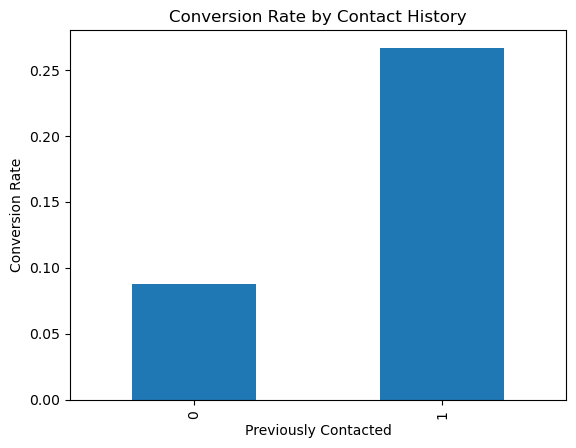

In [61]:
# Conversion by Contact History

import matplotlib.pyplot as plt

merged.groupby("contacted_before")["y_num"].mean().plot(
    kind="bar"
)

plt.title("Conversion Rate by Contact History")
plt.ylabel("Conversion Rate")
plt.xlabel("Previously Contacted")
plt.show()


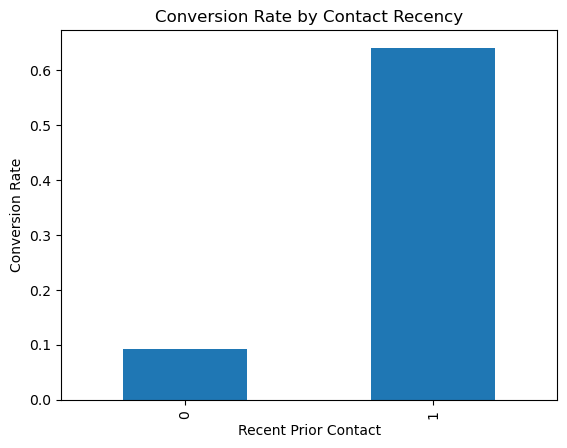

In [62]:
#Convertion by contact history

merged.groupby("recent_contact")["y_num"].mean().plot(
    kind="bar"
)

plt.title("Conversion Rate by Contact Recency")
plt.ylabel("Conversion Rate")
plt.xlabel("Recent Prior Contact")
plt.show()


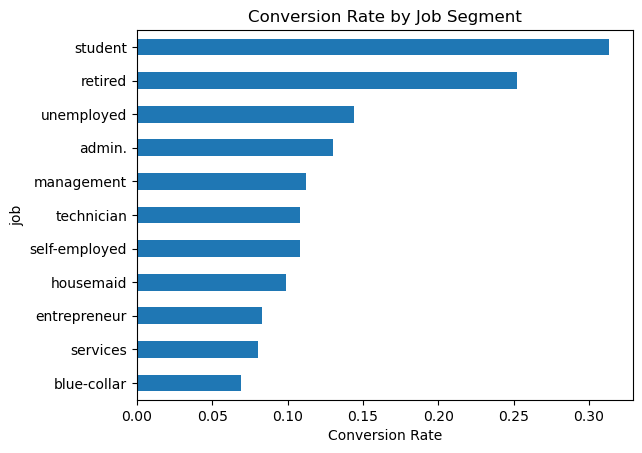

In [63]:
# Convertion by Job

job_conv = (
    merged
    .groupby("job")["y_num"]
    .mean()
    .sort_values()
)

job_conv.plot(kind="barh")

plt.title("Conversion Rate by Job Segment")
plt.xlabel("Conversion Rate")
plt.show()


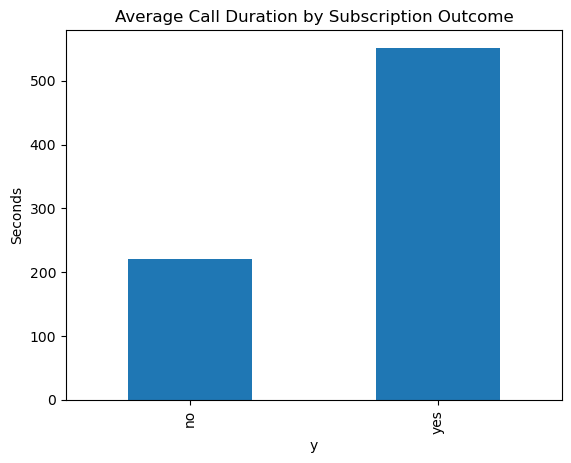

In [64]:
# Duration impact

merged.groupby("y")["duration"].mean().plot(kind="bar")

plt.title("Average Call Duration by Subscription Outcome")
plt.ylabel("Seconds")
plt.show()


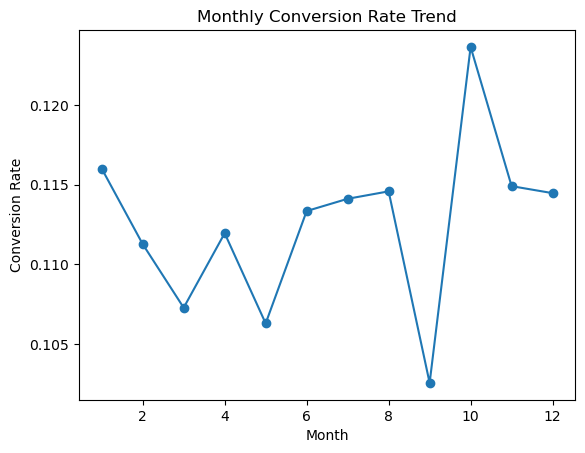

In [70]:
# Temporality trends

merged.groupby("month")["y_num"].mean().plot(kind="line", marker="o")

plt.title("Monthly Conversion Rate Trend")
plt.ylabel("Conversion Rate")
plt.xlabel("Month")
plt.show()


Text(0.5, 0.98, '')

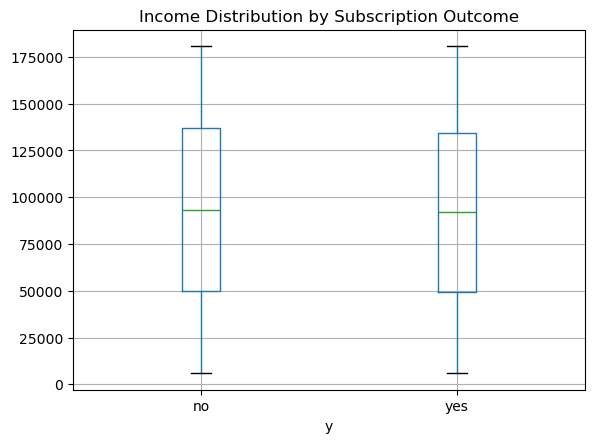

In [71]:
merged.boxplot(column="Income", by="y")
plt.title("Income Distribution by Subscription Outcome")
plt.suptitle("")


Text(0.5, 1.0, 'Conversion Rate by Kids at Home')

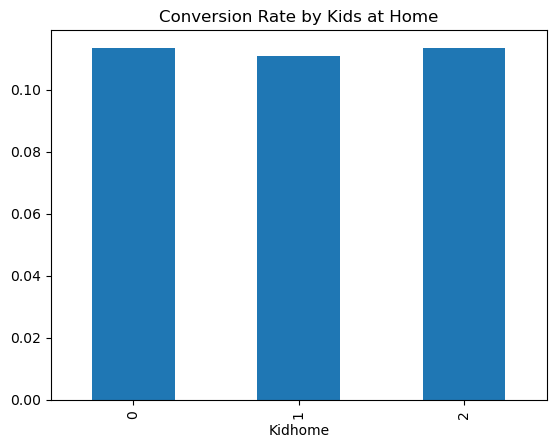

In [72]:
merged.groupby("Kidhome")["y_num"].mean().plot(kind="bar")
plt.title("Conversion Rate by Kids at Home")


# EXECUTIVE DASHBOARD

In [73]:
print("Overall Conversion:", merged["y_num"].mean())
print("Total Clients:", len(merged))
print("Subscribers:", merged["y_num"].sum())
print("Avg Call Duration:", merged["duration"].mean())


Overall Conversion: 0.11265116279069767
Total Clients: 43000
Subscribers: 4844
Avg Call Duration: 257.73927906976746


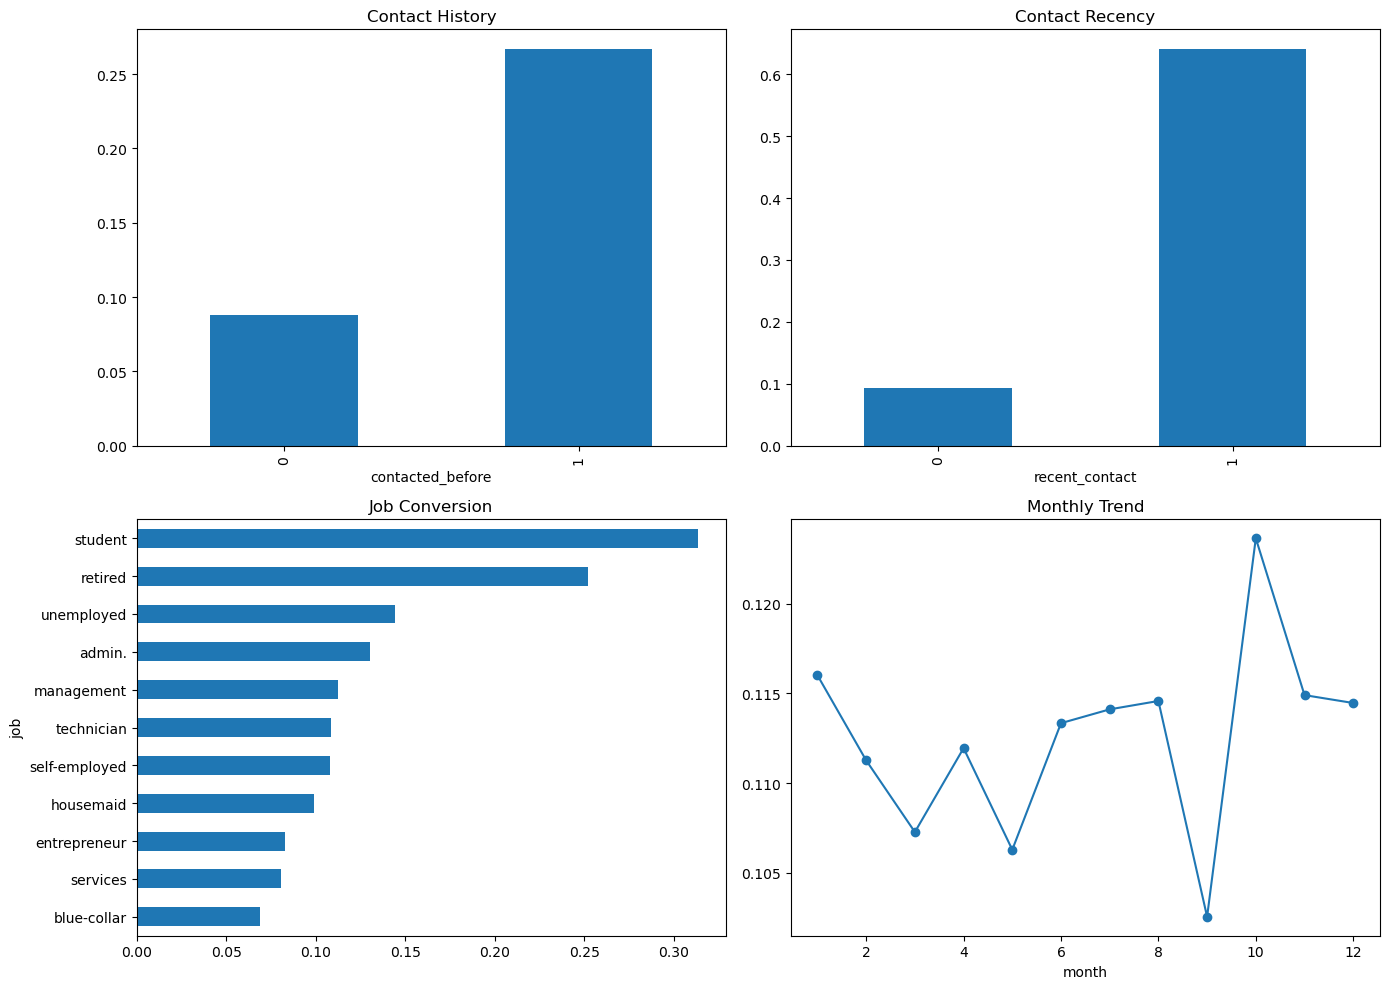

In [74]:
fig, axs = plt.subplots(2, 2, figsize=(14,10))

merged.groupby("contacted_before")["y_num"].mean().plot(
    kind="bar", ax=axs[0,0], title="Contact History"
)

merged.groupby("recent_contact")["y_num"].mean().plot(
    kind="bar", ax=axs[0,1], title="Contact Recency"
)

merged.groupby("job")["y_num"].mean().sort_values().plot(
    kind="barh", ax=axs[1,0], title="Job Conversion"
)

merged.groupby("month")["y_num"].mean().plot(
    kind="line", marker="o", ax=axs[1,1], title="Monthly Trend"
)

plt.tight_layout()
plt.show()
